# GraphQL Anomaly Detection : FeatureResMLP Training

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/graphql-feature-dataset/val.jsonl
/kaggle/input/graphql-feature-dataset/test.jsonl
/kaggle/input/graphql-feature-dataset/train.jsonl


## Imports

In [2]:
import json
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    f1_score,
    confusion_matrix
)
from typing import Dict
import torch.nn.functional as F
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import AutoTokenizer

## Dataset

In [3]:
LABEL_MAP = {
    "normal": 0,
    "malicious": 1,
}

In [4]:
class FeatureDataset(Dataset):
    """
    Expected JSONL format per row:
    {
        "id": "...",
        "label": "normal" | "malicious",
        "features": { ... }
    }
    """

    def __init__(self, jsonl_path: str, feature_keys: list):
        self.feature_keys = feature_keys
        self.samples = []

        with open(jsonl_path, "r", encoding="utf-8") as f:
            for line in f:
                obj = json.loads(line)

                features = obj["features"]
                label = obj["label"]

                x = np.array(
                    [float(features[k]) for k in feature_keys],
                    dtype=np.float32
                )

                y = LABEL_MAP[label]
                self.samples.append((x, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]
        return torch.tensor(x), torch.tensor(y, dtype=torch.float32)

## DataLoaders

In [5]:
def build_feature_dataloaders(
    train_path: str,
    val_path: str,
    feature_keys: list,
    batch_size_train: int = 1024,
    batch_size_val: int = 2048,
    num_workers: int = 0,
):
    train_ds = FeatureDataset(train_path, feature_keys)
    val_ds = FeatureDataset(val_path, feature_keys)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size_train,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size_val,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    return train_loader, val_loader

## Metrics

In [6]:
def compute_classification_metrics(y_true: np.ndarray, y_pred_proba: np.ndarray, threshold: float = 0.5) -> Dict[str, float]:
    """
    y_true: shape (N,) values 0/1
    y_pred_proba: shape (N,) probabilities in [0,1]
    """
    y_true = y_true.astype(int)
    y_pred = (y_pred_proba >= threshold).astype(int)

    metrics = {}
    try:
        metrics["accuracy"] = float(accuracy_score(y_true, y_pred))
        metrics["precision"] = float(precision_score(y_true, y_pred, zero_division=0))
        metrics["recall"] = float(recall_score(y_true, y_pred, zero_division=0))
        metrics["f1"] = float(f1_score(y_true, y_pred, zero_division=0))
    except Exception:
        metrics["accuracy"] = metrics["precision"] = metrics["recall"] = metrics["f1"] = 0.0

    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_pred_proba))
    except Exception:
        metrics["roc_auc"] = float("nan")

    # FPR at high threshold
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    metrics["fpr"] = float(fp / (fp + tn)) if (fp + tn) > 0 else 0.0
    metrics["tpr"] = float(tp / (tp + fn)) if (tp + fn) > 0 else 0.0

    return metrics


## Model

In [7]:
class ResidualBlock(nn.Module):
    """
    One residual block for tabular ResNet-MLP:
    x -> LN -> Linear -> GELU -> Dropout -> Linear -> Dropout -> +x
    """
    def __init__(self, dim: int, dropout: float = 0.2):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fc1 = nn.Linear(dim, dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        h = self.norm(x)
        h = self.fc1(h)
        h = F.gelu(h)
        h = self.dropout(h)
        h = self.fc2(h)
        h = self.dropout(h)
        return residual + h

In [8]:
class FeatureResMLP(nn.Module):
    """
    Strong residual MLP for tabular GraphQL feature vectors.

    Input:
        x: (batch_size, input_dim)
    Output:
        logit: (batch_size,)   # use BCEWithLogitsLoss
    """

    def __init__(
        self,
        input_dim: int,
        width: int = 128,
        num_blocks: int = 4,
        dropout: float = 0.2,
    ):
        super().__init__()

        # Input projection
        self.input_proj = nn.Linear(input_dim, width)

        # Residual trunk
        self.blocks = nn.ModuleList([
            ResidualBlock(width, dropout=dropout)
            for _ in range(num_blocks)
        ])

        # Output head
        self.norm_out = nn.LayerNorm(width)
        self.head = nn.Sequential(
            nn.Linear(width, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),   # binary logit
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        """
        x: FloatTensor of shape (batch_size, input_dim)
        returns: logits (batch_size,)
        """
        h = self.input_proj(x)
        for block in self.blocks:
            h = block(h)
        h = self.norm_out(h)
        logit = self.head(h).squeeze(-1)
        return logit

## Training Configuration

In [9]:
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [10]:
# =========================
# Config
# =========================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ARTIFACT_PATH = "feature_resmlp_best.pt"

FEATURE_KEYS = [
    "num_fields",
    "num_fragments",
    "num_directives",
    "num_aliases",
    "num_operations",
    "num_mutations",
    "num_subscriptions",
    "num_variables",
    "num_arguments",
    "num_introspection_ops",
    "query_depth",
    "avg_depth",
    "branching_factor",
    "node_count",
    "num_nested_selections",
    "estimated_cost",
    "complexity_score",
    "entropy",
    "query_length",
    "num_tokens",
    "has_error",
]

TRAIN_PATH = "/kaggle/input/graphql-feature-dataset/train.jsonl"
VAL_PATH   = "/kaggle/input/graphql-feature-dataset/val.jsonl"

In [11]:
def train():
    train_loader, val_loader = build_feature_dataloaders(
        TRAIN_PATH,
        VAL_PATH,
        FEATURE_KEYS,
    )

    model = FeatureResMLP(input_dim=len(FEATURE_KEYS)).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-3,
        weight_decay=1e-2,
    )

    best_auc = 0.0

    # -----------------------------
    # Metric history (for plots)
    # -----------------------------
    history = {
        "train_loss": [],
        "val_auc": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "val_fpr": [],
    }

    # =============================
    # Training epochs
    # =============================
    for epoch in range(1, 31):
        # -------- TRAIN --------
        model.train()
        epoch_loss = 0.0

        train_pbar = tqdm(
            train_loader,
            desc=f"[FEATURE][Epoch {epoch:02d}] Train",
            leave=False,
        )

        for x, y in train_pbar:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            logits = model(x).squeeze(-1)
            loss = criterion(logits, y)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            train_pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_loss = epoch_loss / len(train_loader)

        # -------- VALIDATION --------
        model.eval()
        all_logits = []
        all_labels = []

        val_pbar = tqdm(
            val_loader,
            desc=f"[FEATURE][Epoch {epoch:02d}] Val",
            leave=False,
        )

        with torch.no_grad():
            for x, y in val_pbar:
                x = x.to(DEVICE)
                y = y.to(DEVICE)

                logits = model(x).squeeze(-1)
                all_logits.append(logits)
                all_labels.append(y)

        logits = torch.cat(all_logits)
        labels = torch.cat(all_labels)

        probs = torch.sigmoid(logits).cpu().numpy()
        y_true = labels.cpu().numpy()

        metrics = compute_classification_metrics(
            y_true=y_true,
            y_pred_proba=probs,
            threshold=0.5,
        )

        # -------- HISTORY LOG --------
        history["train_loss"].append(avg_loss)
        history["val_auc"].append(metrics["roc_auc"])
        history["val_precision"].append(metrics["precision"])
        history["val_recall"].append(metrics["recall"])
        history["val_f1"].append(metrics["f1"])
        history["val_fpr"].append(metrics["fpr"])

        # -------- CHECKPOINT --------
        if metrics["roc_auc"] > best_auc:
            best_auc = metrics["roc_auc"]
            torch.save(model.state_dict(), ARTIFACT_PATH)
            saved = True
        else:
            saved = False

        print(
            f"[FEATURE] Epoch {epoch:02d} | "
            f"Loss={avg_loss:.4f} | "
            f"AUC={metrics['roc_auc']:.4f} | "
            f"P={metrics['precision']:.4f} | "
            f"R={metrics['recall']:.4f} | "
            f"F1={metrics['f1']:.4f} | "
            f"FPR={metrics['fpr']:.4f} | "
            f"Saved={saved}"
        )

    # =============================
    # Save metric history
    # =============================
    with open("feature_resmlp_history.json", "w") as f:
        json.dump(history, f, indent=2)

    print("Training complete. Best AUC:", best_auc)

## Training

In [12]:
print("DEVICE:", DEVICE)
train()

DEVICE: cuda


[FEATURE][Epoch 01] Train:   0%|          | 0/111 [00:00<?, ?it/s]

[FEATURE][Epoch 01] Val:   0%|          | 0/8 [00:00<?, ?it/s]

[FEATURE] Epoch 01 | Loss=0.1983 | AUC=0.9736 | P=0.9761 | R=0.8755 | F1=0.9231 | FPR=0.0132 | Saved=True


[FEATURE][Epoch 02] Train:   0%|          | 0/111 [00:00<?, ?it/s]

...

[FEATURE][Epoch 29] Val:   0%|          | 0/8 [00:00<?, ?it/s]

[FEATURE] Epoch 29 | Loss=0.0957 | AUC=0.9884 | P=0.9975 | R=0.9217 | F1=0.9581 | FPR=0.0014 | Saved=False


[FEATURE][Epoch 30] Train:   0%|          | 0/111 [00:00<?, ?it/s]

[FEATURE][Epoch 30] Val:   0%|          | 0/8 [00:00<?, ?it/s]

[FEATURE] Epoch 30 | Loss=0.0928 | AUC=0.9891 | P=0.9931 | R=0.9320 | F1=0.9616 | FPR=0.0040 | Saved=True
Training complete. Best AUC: 0.9891349700251792


In [13]:
HISTORY_PATH = "feature_resmlp_history.json"

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

history.keys()
# dict_keys(['train_loss', 'val_auc', 'val_precision', 'val_recall', 'val_f1', 'val_fpr'])

dict_keys(['train_loss', 'val_auc', 'val_precision', 'val_recall', 'val_f1', 'val_fpr'])

## Evaluation and Plots

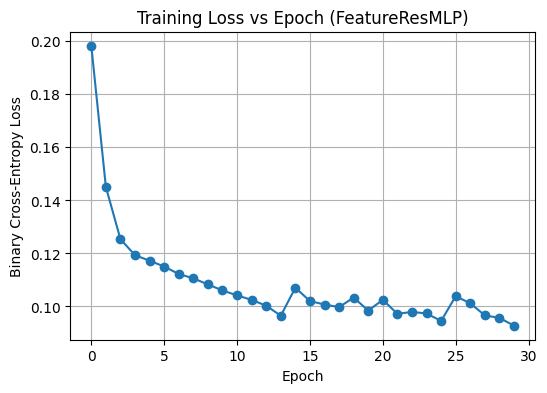

In [14]:
plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], marker="o")
plt.title("Training Loss vs Epoch (FeatureResMLP)")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True)
plt.show()

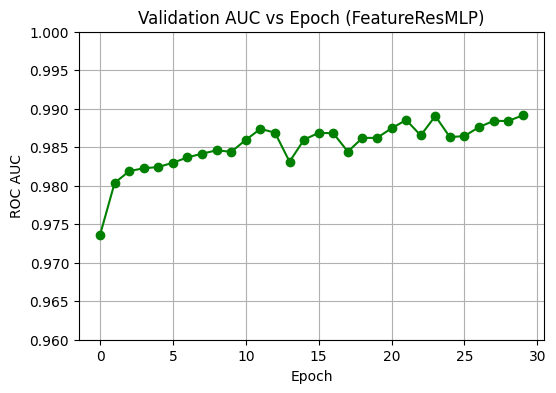

In [15]:
plt.figure(figsize=(6,4))
plt.plot(history["val_auc"], marker="o", color="green")
plt.title("Validation AUC vs Epoch (FeatureResMLP)")
plt.xlabel("Epoch")
plt.ylabel("ROC AUC")
plt.ylim(0.96, 1.0)
plt.grid(True)
plt.show()

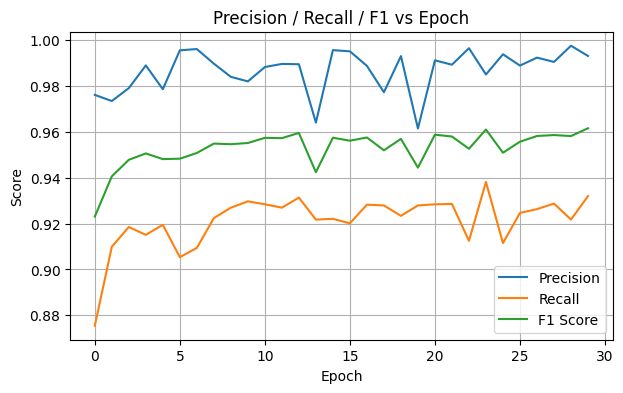

In [16]:
plt.figure(figsize=(7,4))
plt.plot(history["val_precision"], label="Precision")
plt.plot(history["val_recall"], label="Recall")
plt.plot(history["val_f1"], label="F1 Score")
plt.title("Precision / Recall / F1 vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

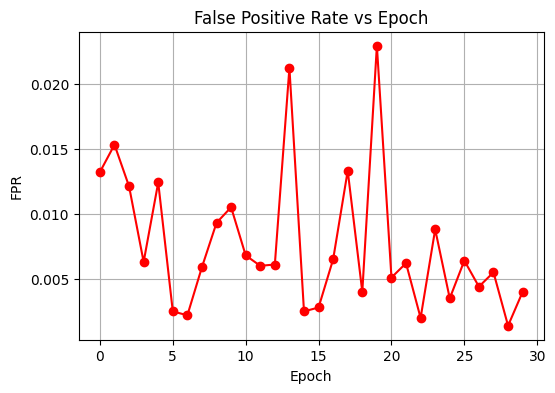

In [17]:
plt.figure(figsize=(6,4))
plt.plot(history["val_fpr"], marker="o", color="red")
plt.title("False Positive Rate vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("FPR")
plt.grid(True)
plt.show()